# GridFM: a neural solver for AC Optimal Power Flow


## Colab setup

Run the next cell first. It clones this branch, installs **only packages Colab is missing**, and puts data/logs under `/content`. It does **not** reinstall PyTorch — that is what OOMs the runtime.

If a previous install already crashed: **Runtime → Disconnect and delete runtime**, then run this cell once.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gridfm/gridfm-graphkit/blob/lfe-tutorial/examples/notebooks/Tutorial_opf_colab.ipynb)

After cloning the repo locally, use `Tutorial_opf.ipynb` instead.


In [ ]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook is for Google Colab. After cloning the repo, open Tutorial_opf.ipynb."
    )

GIT_BRANCH = "lfe-tutorial"
GIT_URL = "https://github.com/gridfm/gridfm-graphkit.git"
REPO = Path("/content/gridfm-graphkit")


def _run(cmd):
    print("+", " ".join(map(str, cmd)))
    subprocess.check_call(cmd)


marker = REPO / "examples" / "notebooks" / "tutorial_opf_helpers.py"
if not marker.is_file():
    _run(["git", "clone", "--depth", "1", "--branch", GIT_BRANCH, GIT_URL, str(REPO)])
else:
    _run(["git", "-C", str(REPO), "fetch", "--depth", "1", "origin", GIT_BRANCH])
    _run(["git", "-C", str(REPO), "reset", "--hard", f"origin/{GIT_BRANCH}"])

# Keep Colab's torch/numpy/pandas. A normal `pip install .` upgrades them and OOMs.
_run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", str(REPO)])
keep = Path("/tmp/colab-keep.txt")
keep.write_text("torch\ntorchaudio\ntorchvision\nnumpy\npandas\n")
need = [
    spec
    for module, spec in (
        ("mlflow", "mlflow"),
        ("lightning", "lightning"),
        ("torch_geometric", "torch-geometric"),
        ("huggingface_hub", "huggingface_hub"),
    )
    if importlib.util.find_spec(module) is None
]
if need:
    _run([sys.executable, "-m", "pip", "install", "-q", "-c", str(keep), *need])
if importlib.util.find_spec("torch_scatter") is None:
    import torch

    _run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-c",
            str(keep),
            "torch-scatter",
            "-f",
            f"https://data.pyg.org/whl/torch-{torch.__version__}.html",
        ]
    )
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
os.chdir(REPO)

CONFIG = REPO / "examples" / "config" / "HGNS_OPF_case118_tutorial.yaml"
assert CONFIG.is_file(), f"Config not found: {CONFIG}"
sys.path.insert(0, str(REPO / "examples" / "notebooks"))

import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

from tutorial_opf_helpers import (
    compare_nb_test_genco_dc,
    compare_scratch_vs_finetune,
    latest_mlflow_run_id,
    link_paper_weights,
    plot_scratch_vs_finetune_val_curves,
    plot_test_gap_and_violations,
    plot_val_residual_boxplot,
    prepare_tutorial_opf_raw,
    solve_one_opf,
)

GENCO = link_paper_weights(REPO, Path("/content/genco_results/opf_2seeds/experiments"))
drive = Path("/content/drive/MyDrive")
DATA = Path("/content/data")
LOG = drive / "gridfm_opf" if drive.exists() else Path("/content/mlruns")
client = MlflowClient(LOG.resolve().as_uri())
print("REPO", REPO)
print("DATA", DATA)
print("LOG", LOG)


## What is AC Optimal Power Flow?

Given a snapshot of the grid (loads, topology, generator costs and limits), AC-OPF finds the **cheapest generator dispatch** that still satisfies power balance and operating limits.

The formulation below is a simplified version of the [PowerModels AC-OPF model](https://lanl-ansi.github.io/PowerModels.jl/stable/math-model/) (bus-injection form). Complex power is $S = P + jQ$.

**Variables**

- $S^g_k$ — complex power of generator $k$
- $V_i$ — complex voltage at bus $i$
- $S_{ij}$ — complex power flow on branch $(i,j)$ (both directions)

**Objective** — minimize quadratic fuel cost of active generation

$$
\min \sum_{k \in G} c_{2k}\, P^g_k{}^2 + c_{1k}\, P^g_k + c_{0k}
\qquad\text{with } P^g_k = \mathrm{Re}(S^g_k)
$$

**Constraints**

1. Reference-bus angle: $\angle V_r = 0$
2. Generator limits: $\underline{S}^g_k \le S^g_k \le \overline{S}^g_k$
3. Voltage limits: $\underline{v}_i \le |V_i| \le \overline{v}_i$
4. Power balance (KCL) at each bus: generation minus load minus shunt equals outgoing branch flows
5. Branch flow from Ohm's law on the $\pi$-model (admittance $Y_{ij}$, tap $T_{ij}$)
6. Thermal limits: $|S_{ij}| \le \overline{s}_{ij}$
7. Angle-difference limits: $\underline{\theta}_{ij} \le \angle(V_i V_j^*) \le \overline{\theta}_{ij}$

Classical solvers (e.g. IPOPT via PowerModels) return a locally optimal $S^g, V, S_{ij}$. A neural OPF solver learns that mapping: **loads + costs + limits → dispatch and voltages**, much faster, with a small optimality gap if the constraints still hold.


Agenda:\
    - loading the data
    - Training a model
    - Evaluating the model



# Load tutorial data

Download `gridfm/opf_small_case118_ieee` from Hugging Face and **copy Hive partitions** into `data/nb_opf_case118/raw/` (`bus_data.parquet/scenario_partition=<n>/`, 200 scenarios each). Do not flatten into a single parquet file — `--compute_dc_ac_metrics` and streaming both expect this layout.


In [27]:
raw = prepare_tutorial_opf_raw(DATA, n_scenarios=1_000)
print("Hive raw at", raw)
print(
    "partitions",
    sorted(p.name for p in (raw / "bus_data.parquet").glob("scenario_partition=*"))[:5],
    "...",
)


Hive raw at /Users/apu/gridfm/gridfm-graphkit/data/nb_opf_case118/raw
partitions ['scenario_partition=0', 'scenario_partition=1', 'scenario_partition=10', 'scenario_partition=11', 'scenario_partition=12'] ...


## GENCO

**GENCO** (GEometric Neural Corrective Optimizer) is a heterogeneous graph transformer that maps a grid snapshot to an AC-OPF solution. It runs $N$ correction steps: each step updates bus and generator embeddings, decodes a candidate $(P_g, V, \theta)$, completes the state with a physics decoder, then feeds power-balance residuals back into the next step.

![GENCO architecture](figures/genco_architecture.png)

### Inputs

The grid is a heterogeneous graph: **bus** nodes, **generator** nodes, directed **branch** edges, and featureless bus–generator links. Unknown OPF variables are zeroed; loads, limits, costs, and topology stay visible.

| Node / edge | What is fed in | YAML |
| --- | --- | --- |
| Bus | $P_d$, $Q_d$, $Q_g$, $V$, $\theta$, PQ/PV/REF flags, $V$ limits, $Q_g$ limits, shunts, $V_n$ | `model.input_bus_dim: 15` |
| Generator | $P_g$, $P_g$ limits, quadratic cost $(c_0, c_1, c_2)$ | `model.input_gen_dim: 6` |
| Branch | admittance, tap, angle limits, thermal rating | `model.edge_dim: 10` |

Width and depth of the latent corrections are `model.hidden_size: 12`, `model.num_layers: 12` (one HT layer per correction step), and `model.attention_head: 8`.

### Outputs

The last correction step is the OPF prediction $x_N$:

- **Buses** — $V$ and $\theta$ (`model.output_bus_dim: 2`). $V$ is mapped into $[\underline{V}, \overline{V}]$ with a sigmoid (the **Sigmoid Bound** / OPF decoder in the figure).
- **Generators** — $P_g$ (`model.output_gen_dim: 1`), likewise boxed into $[\underline{P}_g, \overline{P}_g]$.
- **Completed state** — branch flows from Ohm's law; $Q_g$ recovered from reactive power balance (not a free decoder output).

Ground truth $x^\ast$ is the IPOPT AC-OPF solution stored in the dataset.

### Loss

`training.losses`, `training.loss_weights`, and `training.loss_args` are aligned lists. The objective is the weighted sum

$$
\mathcal{L}
=
0.1\,\mathcal{L}_{\mathrm{phys}}
+
0.1\,\mathcal{L}_{P_g}
+
0.75\,\mathcal{L}_{V,\theta}
+
0.001\,\mathcal{L}_{Q_g}.
$$

| Weight | YAML name | Role |
| --- | --- | --- |
| **0.75** | `MaskedBusMSE` | MSE of predicted vs IPOPT $V$ and $\theta$ (largest term). |
| **0.1** | `MaskedGenMSE` | MSE of predicted vs IPOPT $P_g$. |
| **0.1** | `LayeredWeightedPhysics` | Mean $\ell_2$ power-balance residual at every correction step. Inside this term, `loss_args.base_weight: 0.5` gives geometrically **larger weight to later steps** (same $\lambda^{N-i}$ idea as in the figure), then the weights are normalized to sum to 1. The `0.1` applies to that whole combination. |
| **0.001** | `QgViolationPenalty` | Penalty when recovered $Q_g$ leaves $[\underline{Q}_g, \overline{Q}_g]$. |

So the YAML is telling GENCO: match the IPOPT voltages most strongly, pull generator $P_g$ and physics residuals in more weakly, and keep a small $Q_g$ bound penalty. 

# Training the model

Training uses the same CLI you would run in a terminal. We do **not** reimplement the datamodule, dataloaders, Lightning trainer, or loss loop in this notebook.

```bash
gridfm_graphkit train --config <config.yaml> --data_path <data> --log_dir <logs>
```

That command loads the YAML, builds `LitGridHeteroDataModule` (skipping graph conversion if `processed/` already exists), constructs the OPF task, and runs `trainer.fit`. Hyperparameters stay in the config; the next cells only print that YAML and invoke the same command.


The tutorial uses `examples/config/HGNS_OPF_case118_tutorial.yaml`. The next cell prints that file. What each field does:

**`task`**
- `task_name: OptimalPowerFlow` — predict voltages and generator dispatch (not a power-flow reconstruction task).

**`data`**
- `scenarios: [1000]` — use the first 1,000 scenarios of that network.
- `test_ratio` / `val_ratio` — 10% test, 10% val, remaining ~80% train.
- `mask_value: 0.0` — fill value for masked features.

**`model`** (GENCO)
- `hidden_size`, `num_layers`, `attention_head` — width and depth (12 layers, hidden 12, 8 heads).

**`optimizer`**
- AdamW at `learning_rate: 0.0005`, `betas: [0.9, 0.999]`.
- `ReduceLROnPlateau` multiplies LR by `0.7` after `patience: 5` epochs of no improvement (`mode: min`).

**`training`**
- `batch_size: 64`, `epochs: 10`.
- `accelerator` / `devices` / `strategy: auto` — Lightning device selection (GPU/MPS/CPU).
- Losses (order matches `loss_weights` and `loss_args`):
  - `LayeredWeightedPhysics` (0.1) — power-balance residuals; `base_weight: 0.5` scales deeper layers.
  - `MaskedGenMSE` (0.1) — match \(P_g\) on generators.
  - `MaskedBusMSE` (0.75) — match bus \(V, \theta\).
  - `QgViolationPenalty` (0.001) — penalize reactive generation outside limits.


In [28]:
print(CONFIG.read_text())


version: 1
# Tutorial OPF config: 1,000-scenario slice of gridfm/opf_small_case118_ieee.
# Model and loss match HGNS_OPF_datakit_case118.yaml; only budget knobs differ.
task:
  task_name: OptimalPowerFlow
data:
  baseMVA: 100
  mask_value: 0.0
  normalization: HeteroDataMVANormalizer
  networks:
  - nb_opf_case118
  scenarios:
  - 1000
  test_ratio: 0.1
  val_ratio: 0.1
  workers: 16
  split_by_load_scenario_idx: true
  stream_partitions: auto
model:
  attention_head: 8
  edge_dim: 10
  hidden_size: 12
  input_bus_dim: 15
  input_gen_dim: 6
  output_bus_dim: 2
  output_gen_dim: 1
  num_layers: 12
  type: GNS_heterogeneous
optimizer:
  type: AdamW
  learning_rate: 0.0005
  optimizer_params:
    betas: [0.9, 0.999]
  scheduler_type: ReduceLROnPlateau
  scheduler_params:
    mode: min
    factor: 0.7
    patience: 5
seed: 0
training:
  batch_size: 64
  epochs: 10
  losses:
  - LayeredWeightedPhysics
  - MaskedGenMSE
  - MaskedBusMSE
  - QgViolationPenalty
  loss_weights:
  - 0.1
  - 0.1
 

In [29]:
!gridfm_graphkit train \
  --config {CONFIG} \
  --data_path {DATA} \
  --log_dir {LOG} \
  --exp_name tutorial_opf \
  --log_every_n_steps 50 \
  --compute_dc_ac_metrics


Seed set to 0
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/apu/gridfm/gridfm-graphkit/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
[device] hostname=Pfungen
[device] Using Apple MPS (Metal Performance Shaders)
Fitting normalizer on train set (796 scenarios)

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | GNS_heterogeneous | 1.3 M  | train
1 | loss_fn | MixedLoss         | 0      | train
------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.106     Total estimated model params size (MB)
355       Modules in train mode
0         Modules in eval mode
Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]/Users/apu/gridfm/grid

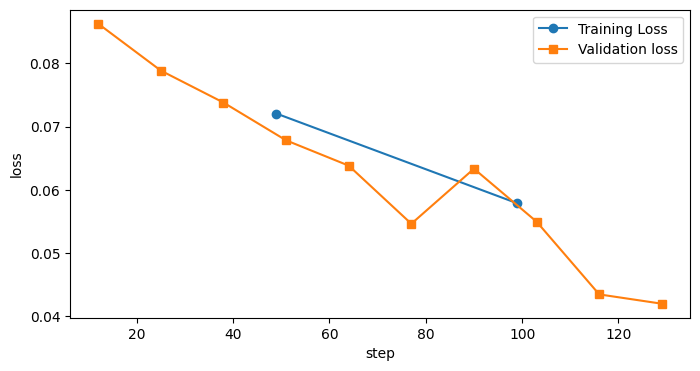

In [30]:
rid = client.search_runs(
    [e.experiment_id for e in client.search_experiments()],
    order_by=["start_time DESC"],
    max_results=1,
)[0].info.run_id


def hist(name):
    try:
        h = sorted(client.get_metric_history(rid, name), key=lambda m: m.step)
    except Exception:
        return [], []
    return [m.step for m in h], [m.value for m in h]


fig, ax = plt.subplots(figsize=(8, 4))
for name, fmt in (
    ("Training Loss", "o-"),
    ("Training Loss_step", "o-"),
    ("Validation loss", "s-"),
):
    s, v = hist(name)
    if v:
        ax.plot(s, v, fmt, label=name)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend()
plt.show()


After each correction step, GENCO decodes $(P_g, V, \theta)$, completes flows from Ohm's law, and checks **nodal power balance**. The mismatch is a complex residual per bus

$$
\Delta S_k = \Delta P_k + j\,\Delta Q_k,
\qquad
\Delta P_k = P_{g,k}-P_{d,k}+P_{\mathrm{shunt},k}-P_{\mathrm{inj},k},
\quad
\Delta Q_k = Q_{g,k}-Q_{d,k}+Q_{\mathrm{shunt},k}-Q_{\mathrm{inj},k}.
$$

The curve below is **`Validation layer_11_residual`**: mean over buses of $|\Delta S_k|=\sqrt{\Delta P_k^2+\Delta Q_k^2}$ on the **validation set**, at **layer 11** (last of `num_layers: 12`). That is the complex power-balance residual of the final OPF prediction $x_N$ (PBRes$^N$ in the architecture figure), in per-unit.

A **downward** trend means the decoded voltages and dispatch are getting closer to satisfying KCL: less leftover $P$ and $Q$ at the buses. The physics term in the YAML (`LayeredWeightedPhysics`) is what pushes this down, on **held-out load scenarios** of the same grid (the validation split), not a different network.

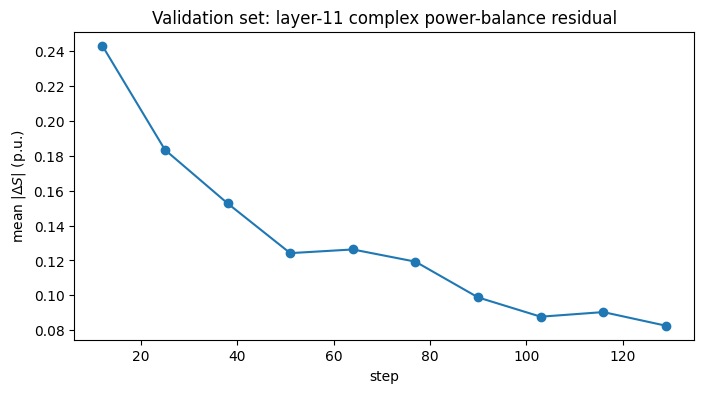

In [31]:
s, v = hist("Validation layer_11_residual")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s, v, "o-")
ax.set_xlabel("step")
ax.set_ylabel(r"mean $|\Delta S|$ (p.u.)")
ax.set_title("Validation set: layer-11 complex power-balance residual")
plt.show()


GENCO is built as a **corrective** solver: each layer proposes a candidate OPF state, measures how far it is from power balance, and feeds that residual into the next layer. If that design works, $|\Delta S|$ on held-out scenarios should **shrink with depth** — later layers closer to KCL than early ones, with the last layer the tightest.

The box plot is that check on the **validation set** after training: one box per layer, the spread of per-bus complex power-balance residuals. A downward shift across layers confirms the iterative physics feedback is actually refining the solution, not just fitting IPOPT voltages in a single shot.


Fitting normalizer on train set (796 scenarios)


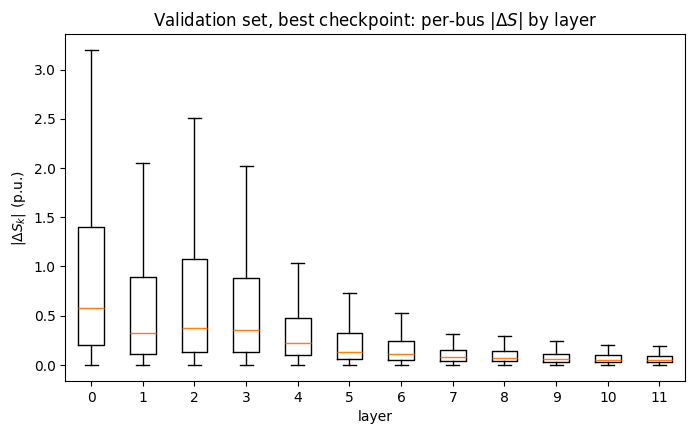

In [32]:
plot_val_residual_boxplot(CONFIG, DATA, client, rid);


Same val batches, **trained checkpoint overlaid on random init**. Stacking layers alone should not systematically drive $|\Delta S|$ down; if it did, the trained drop would not be evidence of learned corrections. Large random-init residuals at every depth, with no clear decline, is the control we want.

Fitting normalizer on train set (796 scenarios)


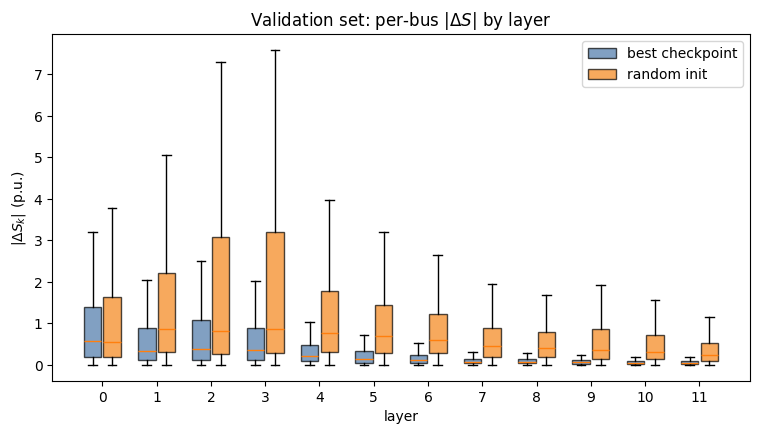

In [33]:
plot_val_residual_boxplot(CONFIG, DATA, client, rid, overlay=True);


We now look at **test-set** results: the held-out 10% of this notebook run (same scenario split as training). The table compares the Tiny GENCO we just trained to DC-OPF on that split. Both columns are read from MLflow `artifacts/test/` (`*_metrics.csv` for GENCO, `*_opf_ac_dc_metrics.csv` for DC-OPF).


In [34]:
compare_nb_test_genco_dc(client, rid)


Test set (107 scenarios, run 66d1c02f…) from /Users/apu/gridfm/gridfm-graphkit/mlruns/450897086427353776/66d1c02f360e487e8e328ef947293320/artifacts/test


,metric,GENCO,DC-OPF
0,Mean optimality gap (%),10.8725,4.8245
1,Avg. active res. (MW),9.3934,2.5371
2,Avg. reactive res. (MVar),4.6298,NaN
3,Thermal viol. from (MVA),0.0195,0.1218
4,Thermal viol. to (MVA),0.0178,0.1208
5,Mean Qg violation (MVar),11.0812,NaN


These test numbers are **too weak** — Tiny loses to DC-OPF here because we did not train long enough (and not on enough data). This notebook run is **10 epochs** on **1,000** scenarios with `hidden_size: 12` (~1.3M parameters).

The IEEE 118 **Small** model in the paper was trained for **200 epochs** on the full Datakit **250,000** scenarios with `hidden_size: 24` (~5M parameters). The loss, optimizer, and LR schedule (`ReduceLROnPlateau`, factor 0.7, patience 5) are the same; what changed is the budget: more data, more epochs, and a wider model. The next cells load that paper checkpoint.


# Evaluate GENCO Small (paper checkpoint)

The Tiny run above was trained in this notebook (`hidden_size: 12`). The paper's **Small** model uses `hidden_size: 24` (~5M parameters). The next cell loads seed-1 of `HGNS_OPF_datakit_case118_small` from `opf_2seeds` and runs `gridfm_graphkit evaluate` with that run's weights and `normalizer_stats.pt`. The YAML uses `networks: [case118_ieee]` so the stats key matches; `data/case118_ieee` is a symlink to the tutorial slice.


In [35]:
CONFIG_SMALL = REPO / "examples" / "config" / "HGNS_OPF_case118_small.yaml"
SMALL_RUN = GENCO / "465594abc8eb4c96b908363afc84a0e1"
MODEL_PATH = SMALL_RUN / "artifacts" / "model" / "best_model_state_dict.pt"
NORM_PATH = SMALL_RUN / "artifacts" / "stats" / "normalizer_stats.pt"
assert MODEL_PATH.is_file(), f"Missing checkpoint: {MODEL_PATH}"
assert NORM_PATH.is_file(), f"Missing normalizer: {NORM_PATH}"

!gridfm_graphkit evaluate \
  --config {CONFIG_SMALL} \
  --data_path {DATA} \
  --log_dir {LOG} \
  --exp_name tutorial_opf_eval_small \
  --model_path {MODEL_PATH} \
  --normalizer_stats {NORM_PATH} \
  --compute_dc_ac_metrics


Seed set to 0
Loading model weights from /Users/apu/gridfm/genco_results/opf_2seeds/experiments/465594abc8eb4c96b908363afc84a0e1/artifacts/model/best_model_state_dict.pt
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
[device] hostname=Pfungen
[device] Using Apple MPS (Metal Performance Shaders)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Loaded normalizer stats from /Users/apu/gridfm/genco_results/opf_2seeds/experiments/465594abc8eb4c96b908363afc84a0e1/artifacts/stats/normalizer_stats.pt
Restoring normalizer for case118_ieee from saved stats
Testing: |                                                | 0/? [00:00<?, ?it/s]/Users/apu/gridfm/gridfm-gra

In [36]:
eval_exp = [e for e in client.search_experiments() if e.name == "tutorial_opf_eval_small"]
eval_rid = client.search_runs(
    [eval_exp[0].experiment_id],
    order_by=["start_time DESC"],
    max_results=1,
)[0].info.run_id
compare_nb_test_genco_dc(client, eval_rid)


Test set (107 scenarios, run a38e9ee4…) from /Users/apu/gridfm/gridfm-graphkit/mlruns/919058505556949684/a38e9ee40b644b69918a015c0da486ac/artifacts/test


,metric,GENCO,DC-OPF
0,Mean optimality gap (%),1.1580,4.8245
1,Avg. active res. (MW),0.9715,2.5371
2,Avg. reactive res. (MVar),0.2361,NaN
3,Thermal viol. from (MVA),0.0525,0.1218
4,Thermal viol. to (MVA),0.0311,0.1208
5,Mean Qg violation (MVar),0.0000,NaN


## Solve one OPF

A trained GENCO checkpoint **is** the solver: one forward pass on a grid snapshot. No IPOPT, no iterative Newton loop at inference — just decode $(P_g, V, \theta)$ and complete $Q_g$ and flows from physics.

The cell below loads the paper **Small** checkpoint (same weights as the evaluation above), takes the **first validation scenario** on IEEE 118, and prints generator dispatch and bus voltages next to the IPOPT AC-OPF labels and the DC-OPF solution stored in the dataset.


In [37]:
solve_one_opf(
    CONFIG_SMALL,
    DATA,
    model_path=MODEL_PATH,
    normalizer_stats=NORM_PATH,
)


Loaded normalizer stats from /Users/apu/gridfm/genco_results/opf_2seeds/experiments/465594abc8eb4c96b908363afc84a0e1/artifacts/stats/normalizer_stats.pt
Restoring normalizer for case118_ieee from saved stats


Validation scenario 18828  (one GENCO forward pass)


,cost GENCO,cost IPOPT,cost DC,gap GENCO %,gap DC %,mean |ΔS| GENCO (MVA),mean |ΔP| GENCO (MW),mean |ΔP| DC (MW)
0,95283.0312,95997.8984,92070.0156,-0.7447,-4.0916,0.5774,0.4702,2.3469


Generator dispatch (dispatchable only)


,gen,Pg GENCO (MW),Pg IPOPT (MW),Pg DC (MW),min,max
0,4,182.018005,199.602005,187.358,0.0,505.0
1,5,82.438004,85.000000,85.000,0.0,85.0
2,10,220.783005,221.000000,221.000,0.0,221.0
3,11,445.170990,465.871002,429.521,0.0,485.0
4,13,15.736000,17.000000,17.000,0.0,17.0
5,19,19.982000,20.000000,20.000,0.0,20.0
6,20,222.774994,223.000000,223.000,0.0,223.0
7,21,52.026001,53.000000,53.000,0.0,53.0
8,24,293.645996,295.502991,254.659,0.0,308.0
9,25,190.701996,195.000000,195.000,0.0,195.0


Average abs. Pg deviation: GENCO 4.06%, DC 14.28% (vs |Pg_IPOPT|, dispatchable gens with |Pg| > 1 MW)
Bus voltages and injections


,bus,type,Vm GENCO,Vm IPOPT,|ΔP| GENCO (MW),|ΔP| DC (MW)
0,0,PV,1.016,0.975,0.583,0.101
1,1,PQ,1.022,0.981,0.220,0.136
2,2,PQ,1.024,0.981,0.278,0.488
3,3,PV,1.052,1.004,0.932,0.343
4,4,PQ,1.049,1.000,0.702,3.029
...,...,...,...,...,...,...
113,113,PQ,1.032,1.043,0.224,0.005
114,114,PQ,1.033,1.044,0.848,0.119
115,115,PV,1.029,1.060,0.574,0.076
116,116,PQ,1.019,0.979,0.116,0.084


The tables above are **one** validation snapshot. The next cell runs the same Small checkpoint on the **full test split** and overlays GENCO vs DC-OPF distributions of optimality gap and constraint violations (mean over buses or branches in each scenario).


Loaded normalizer stats from /Users/apu/gridfm/genco_results/opf_2seeds/experiments/465594abc8eb4c96b908363afc84a0e1/artifacts/stats/normalizer_stats.pt
Restoring normalizer for case118_ieee from saved stats
Test samples: 107


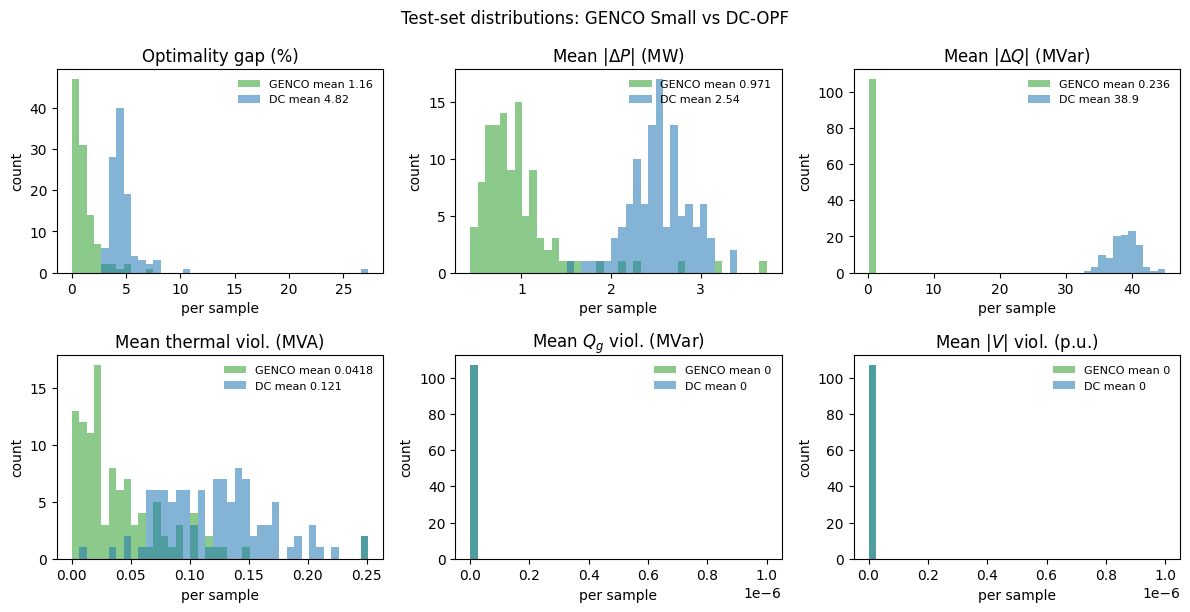

In [38]:
plot_test_gap_and_violations(CONFIG_SMALL, DATA, MODEL_PATH, NORM_PATH)


IEEE 118 and the paper's 2,000-bus grid are **different networks**. The question here is transfer: if GENCO has already learned AC-OPF on a large synthetic grid, do those weights help on IEEE 118 when you only have **1,000** labeled snapshots?

The case2000 **Small** checkpoint (`HGNS_OPF_datakit_case2000_small_seed1`, `hidden_size: 24`, 12 layers) matches this YAML, so `load_state_dict` works. Physics is the same; topology, limits, and load patterns are not. **Scratch** trains that width from random init for 20 epochs on this 1,000-scenario slice. **Fine-tune** starts from the case2000 weights and adapts them to 118. There is no Tiny (`hidden_size: 12`) case2000 run in `opf_2seeds`.


In [39]:
CONFIG_FEW_SMALL = REPO / "examples" / "config" / "HGNS_OPF_case118_fewshot_small.yaml"
PRETRAINED_2K_SMALL = (
    GENCO / "f227514415974447befc64513a758432" / "artifacts" / "model" / "best_model_state_dict.pt"
)
assert CONFIG_FEW_SMALL.is_file(), f"Missing config: {CONFIG_FEW_SMALL}"
assert PRETRAINED_2K_SMALL.is_file(), f"Missing case2000 Small checkpoint: {PRETRAINED_2K_SMALL}"

!gridfm_graphkit train \
  --config {CONFIG_FEW_SMALL} \
  --data_path {DATA} \
  --log_dir {LOG} \
  --exp_name tutorial_opf_scratch_case2000_small20 \
  --log_every_n_steps 10 \
  --compute_dc_ac_metrics \
  --num_workers 16

!gridfm_graphkit finetune \
  --config {CONFIG_FEW_SMALL} \
  --data_path {DATA} \
  --log_dir {LOG} \
  --exp_name tutorial_opf_ft_case2000_small \
  --model_path {PRETRAINED_2K_SMALL} \
  --log_every_n_steps 10 \
  --compute_dc_ac_metrics \
  --num_workers 16

compare_scratch_vs_finetune(
    client,
    latest_mlflow_run_id(client, "tutorial_opf_scratch_case2000_small20"),
    latest_mlflow_run_id(client, "tutorial_opf_ft_case2000_small"),
)


Seed set to 0
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
[device] hostname=Pfungen
[device] Using Apple MPS (Metal Performance Shaders)
Fitting normalizer on train set (796 scenarios)

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | GNS_heterogeneous | 5.0 M  | train
1 | loss_fn | MixedLoss         | 0      | train
------------------------------------------------------
5.0 M     Trainable params
0         Non-trainable params
5.0 M     Total params
20.188    Total estimated model params size (MB)
355       Modules in train mode
0         Modules in eval mode
Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]/Users/apu/gridfm/gridfm-graphkit/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:377: You have overridden `transfer_batch_to_device` in `LightningModule` but have passed i

,metric,scratch,finetune,DC-OPF
0,Mean optimality gap (%),12.2163,7.0867,4.8245
1,Avg. active res. (MW),7.6677,5.6753,2.5371
2,Avg. reactive res. (MVar),1.6083,0.8740,NaN
3,Thermal viol. from (MVA),0.0543,0.1428,0.1218
4,Mean Qg violation (MVar),10.1534,1.2315,NaN


Validation curves for the two 20-epoch runs above: **scratch** vs **case2000 Small finetune**. Left is `Validation loss`; middle is last-layer power-balance residual (`Validation layer_11_residual`). The right panel is **test-set mean optimality gap** for both models and **DC-OPF** (same test split as the table above).

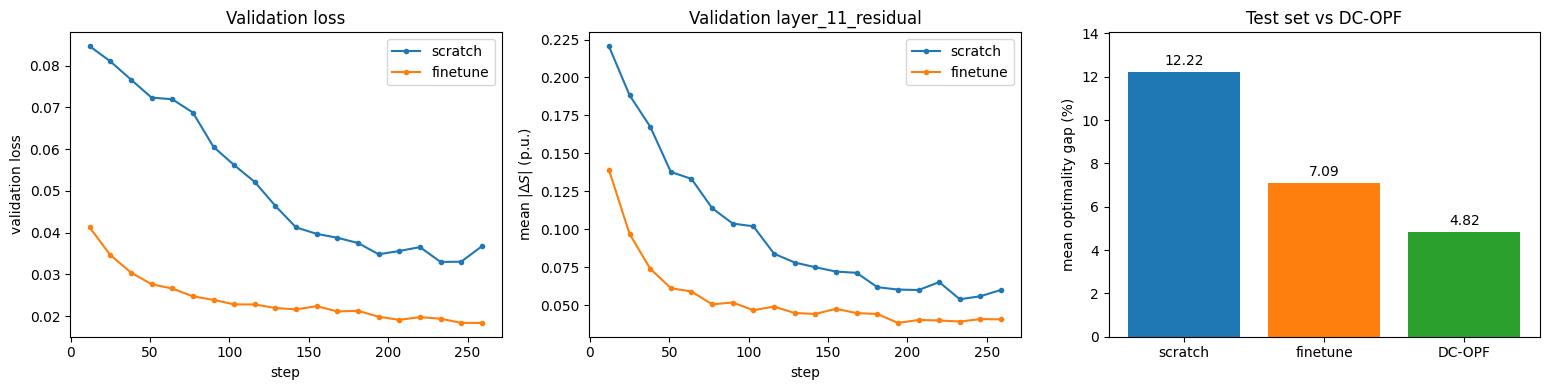

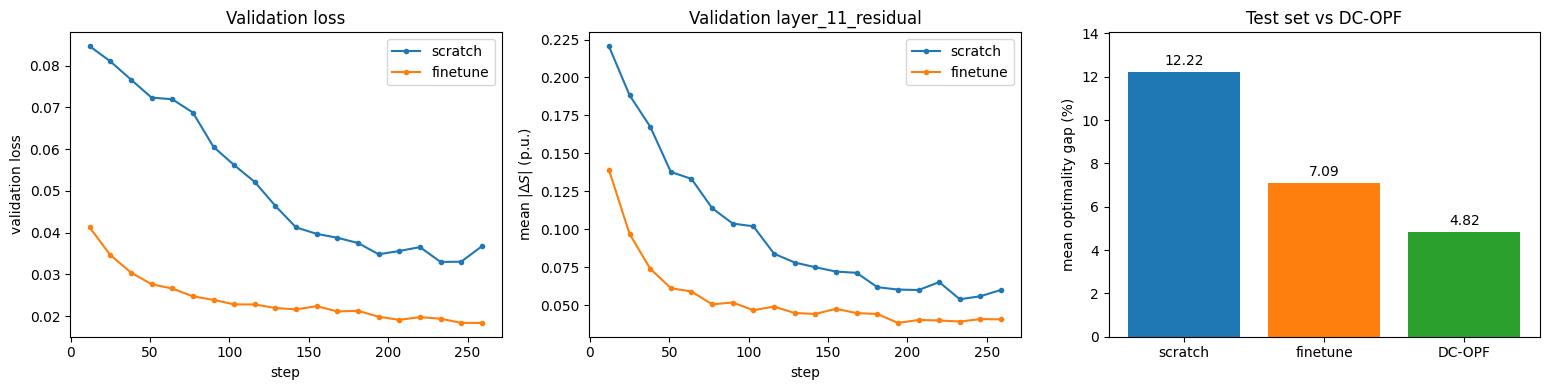

In [40]:
plot_scratch_vs_finetune_val_curves(
    client,
    latest_mlflow_run_id(client, "tutorial_opf_scratch_case2000_small20"),
    latest_mlflow_run_id(client, "tutorial_opf_ft_case2000_small"),
)
